# Inverzní analýza: Prohnutí nosníku, modul pružnosti E



Prostě podepřený nosník, síla uprostřed rozpětí. 

Průhyb uprostřed:

$$f = \frac{F L^3}{48 E I}$$

Mám průhyb pro několik různých sil a z těchto dat chci zpětně
dostat modul pružnosti $E$. 
Používám Bayesovu metodu pomocí Markov Chain Monte Carlo.
Plný modelu bude porovnán s PCE.

Postup:
1. fyzikální model + naměřená data
2. MCMC na plném modelu
3. PCE náhrada modelu
4. MCMC na PCE náhradě
5. porovnání obou přístupů

Podklady:
- https://uqpyproject.readthedocs.io/en/latest/auto_examples/inference/bayes_parameter_estimation/
- https://uqpyproject.readthedocs.io/en/latest/surrogates/polynomial_chaos.html


In [20]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import dill, time, os

from UQpy.distributions import Uniform, JointIndependent, Normal
from UQpy.run_model.RunModel import RunModel
from UQpy import PythonModel
from UQpy.inference.inference_models.ComputationalModel import ComputationalModel
from UQpy.inference import BayesParameterEstimation
from UQpy.sampling.mcmc.MetropolisHastings import MetropolisHastings
from UQpy.surrogates.polynomial_chaos.polynomials.TotalDegreeBasis import TotalDegreeBasis
from UQpy.surrogates.polynomial_chaos.regressions.LeastSquareRegression import LeastSquareRegression
from UQpy.surrogates.polynomial_chaos.PolynomialChaosExpansion import PolynomialChaosExpansion

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True

# acceptance_rate mi jednou vrati cislo a jindy pole (podle verze UQpy) - abych se
# na to nemusel poporad divat, udelam si jednu pomocnou funkci
def acc_rate(mcmc):
    r = mcmc.acceptance_rate
    return r[0] if hasattr(r, '__len__') else r

print("nacteni knihoven ok")


nacteni knihoven ok


## 1) Fyzikální model a naměřená data

In [22]:
# rozmery nosniku a "skutecna" hodnota E, kterou budu na konci ze simulovaneho mereni zpetne odhadovat
L = 2.0          # delka nosniku [m]
I_MOM = 4.0e-6   # kvadraticky moment prurezu [m^4]
E_TRUE = 210e9   # [Pa], pro ocel

F_GRID = np.array([1000., 2000., 3000., 4000., 5000., 6000., 7000., 8000.])  #  sily [N]

def prehyb_nosniku(F, E, L=L, I=I_MOM):
    return F * L**3 / (48.0 * E * I)

f_teoreticke = prehyb_nosniku(F_GRID, E_TRUE)

# f = F*L^3 / (48*E*I)
print(f"\nL={L} m, I={I_MOM:.1e} m^4, E_TRUE={E_TRUE:.2e} Pa")
for F_i, f_i in zip(F_GRID, f_teoreticke):
    print(f"F = {F_i:6.0f} N  ->  f = {f_i*1000:6.3f} mm")



L=2.0 m, I=4.0e-06 m^4, E_TRUE=2.10e+11 Pa
F =   1000 N  ->  f =  0.198 mm
F =   2000 N  ->  f =  0.397 mm
F =   3000 N  ->  f =  0.595 mm
F =   4000 N  ->  f =  0.794 mm
F =   5000 N  ->  f =  0.992 mm
F =   6000 N  ->  f =  1.190 mm
F =   7000 N  ->  f =  1.389 mm
F =   8000 N  ->  f =  1.587 mm


In [23]:
# realny senzor nemeri presne, proto pridam se sum.   nahodne gaussovske odchylky k teoretickym pruhybum
SENSOR_STD = 1.0e-5  # smerodatna odchylka senzoru [m], cca 0.01 mm

sum_senzoru = Normal(loc=0., scale=SENSOR_STD).rvs(nsamples=len(F_GRID), random_state=2024).reshape(-1)
data_mereni = f_teoreticke + sum_senzoru

print("Nasymulovana data:")
for F_i, d_i, t_i in zip(F_GRID, data_mereni, f_teoreticke):
    print(f"F = {F_i:6.0f} N  ->  namereno {d_i*1000:6.3f} mm   (teorie {t_i*1000:6.3f} mm, rozdil {(d_i-t_i)*1000:+.3f} mm)")


Nasymulovana data:
F =   1000 N  ->  namereno  0.215 mm   (teorie  0.198 mm, rozdil +0.017 mm)
F =   2000 N  ->  namereno  0.404 mm   (teorie  0.397 mm, rozdil +0.007 mm)
F =   3000 N  ->  namereno  0.593 mm   (teorie  0.595 mm, rozdil -0.002 mm)
F =   4000 N  ->  namereno  0.792 mm   (teorie  0.794 mm, rozdil -0.002 mm)
F =   5000 N  ->  namereno  1.001 mm   (teorie  0.992 mm, rozdil +0.009 mm)
F =   6000 N  ->  namereno  1.202 mm   (teorie  1.190 mm, rozdil +0.012 mm)
F =   7000 N  ->  namereno  1.363 mm   (teorie  1.389 mm, rozdil -0.026 mm)
F =   8000 N  ->  namereno  1.574 mm   (teorie  1.587 mm, rozdil -0.013 mm)


## 2) Model v `UQpy.RunModel`

MCMC (Qpy nepracuje) s funkcí přímo, ale s modelem zabaleným do třídym RunModel
Umělé zpomalení time.sleep, pro simulaci MKP vs PCE

In [25]:
%%writefile beam_model.py
#  musi byt samostatny .py soubor
import numpy as np, time

L, I_MOM = 2.0, 4.0e-6
F_GRID = np.array([1000., 2000., 3000., 4000., 5000., 6000., 7000., 8000.])
NAROCNOST_MODELU = 0.02  # [s] - umele zpomaleni, jako by slo o drahou simulaci

def model_prehybu(samples):
    time.sleep(NAROCNOST_MODELU)
    E = float(samples[0])
    return F_GRID * L**3 / (48.0 * E * I_MOM)


Overwriting beam_model.py


In [26]:
NAROCNOST_MODELU = 0.02  # stejna hodnota jako v beam_model.py

model_full = PythonModel(model_script='beam_model.py', model_object_name='model_prehybu', var_names=['E'])
h_func_full = RunModel(model=model_full)

t0 = time.time()
h_func_full.run(samples=np.array([[E_TRUE]]))
t1 = time.time()
vysledek = np.array(h_func_full.qoi_list[0])

# kontrola, ze model zabaleny v RunModelu dava presne stejne cislo jako primy vzorec -
print("RunModel:     ", np.round(vysledek*1000, 4), "mm")
print("primy vzorec: ", np.round(f_teoreticke*1000, 4), "mm")
assert np.allclose(vysledek, f_teoreticke), "RunModel nedava to, co primy vypocet!"

RunModel:      [0.1984 0.3968 0.5952 0.7937 0.9921 1.1905 1.3889 1.5873] mm
primy vzorec:  [0.1984 0.3968 0.5952 0.7937 0.9921 1.1905 1.3889 1.5873] mm


## 3)MCMC na plném modelu

Přesnou hodnotu E neznám, vím o ní jen to, že leží někde mezi 100 a 350 GPa prior.
Spolu s naměřenými daty a předpokladem gaussovského šumu senzoru likelihood mi MCMC
dá posterior – rozdělení pravděpodobnosti hodnot E, které jsou s daty konzistentní.

MCMC spouštím po blocích, abych průběžně viděl, jestli řetězec konverguje.

In [28]:
prior_E = Uniform(loc=100e9, scale=250e9)   # E ~ Uniform(100, 350) GPa
prior = JointIndependent(marginals=[prior_E])
error_covariance = SENSOR_STD ** 2          # rozptyl sumu senzoru, pouzity jako chyba v likelihoodu

inference_model_full = ComputationalModel(n_parameters=1, runmodel_object=h_func_full,
                                           error_covariance=error_covariance, prior=prior)

# kontrola, ze E_TRUE vubec lezi v prioru 
v_prioru = 100e9 <= E_TRUE <= 350e9
print(f"prior: Uniform(100, 350) GPa | E_TRUE v prioru: {v_prioru}")
assert v_prioru


prior: Uniform(100, 350) GPa | E_TRUE v prioru: True


In [29]:
proposal = Normal(scale=3e9)
mcmc_full = MetropolisHastings(jump=2, burn_length=100, proposal=proposal, seed=[160e9], random_state=42)
bayes_full = BayesParameterEstimation(inference_model=inference_model_full, data=data_mereni,
                                       sampling_class=mcmc_full, nsamples=None)

KROK, POCET_KROKU = 200, 5   # 5 x 200 = 1000 vzorku celkem
print("pocitam MCMC na plnem modelu ..")
t_start_full = time.time()
for k in range(1, POCET_KROKU + 1):
    bayes_full.run(nsamples=KROK)
    v = mcmc_full.samples[:, 0]
    print(f"blok {k}/{POCET_KROKU} | n={len(v):4d} | E = {v.mean()/1e9:7.2f} +/- {v.std()/1e9:5.2f} GPa | prijeti={acc_rate(mcmc_full):.2f}")
cas_full = time.time() - t_start_full
print(f"hotovo za {cas_full:.1f} s")


pocitam MCMC na plnem modelu ..
blok 1/5 | n= 200 | E =  210.80 +/-  0.84 GPa | prijeti=0.34
blok 2/5 | n= 400 | E =  210.80 +/-  0.78 GPa | prijeti=0.33
blok 3/5 | n= 600 | E =  210.82 +/-  0.75 GPa | prijeti=0.33
blok 4/5 | n= 800 | E =  210.85 +/-  0.74 GPa | prijeti=0.32
blok 5/5 | n=1000 | E =  210.85 +/-  0.75 GPa | prijeti=0.32
hotovo za 45.3 s


posterior E (plny model): 210.85 +/- 0.75 GPa
95% interval spolehlivosti: [209.41, 212.34] GPa
E_TRUE = 210.00 GPa, relativni chyba odhadu = 0.41 %
OK - E_TRUE lezi v 95% intervalu spolehlivosti


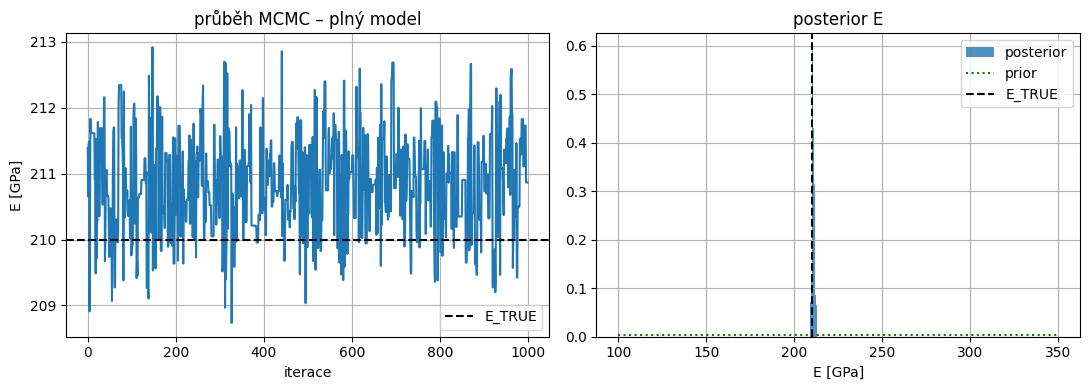

In [30]:
vzorky_full = mcmc_full.samples[:, 0]
odhad_full = vzorky_full.mean()
chyba_full = abs(odhad_full - E_TRUE) / E_TRUE * 100
ci_low, ci_high = np.percentile(vzorky_full, [2.5, 97.5])

print(f"posterior E (plny model): {odhad_full/1e9:.2f} +/- {vzorky_full.std()/1e9:.2f} GPa")
print(f"95% interval spolehlivosti: [{ci_low/1e9:.2f}, {ci_high/1e9:.2f}] GPa")
print(f"E_TRUE = {E_TRUE/1e9:.2f} GPa, relativni chyba odhadu = {chyba_full:.2f} %")

# hlavni kontrola spravnosti cele inverze: skutecna hodnota by mela padnout do 95%
# intervalu. 
if ci_low <= E_TRUE <= ci_high:
    print("OK - E_TRUE lezi v 95% intervalu spolehlivosti")
else:
    print("POZOR - E_TRUE je mimo 95% interval")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(vzorky_full/1e9)
ax[0].axhline(E_TRUE/1e9, color='k', ls='--', label='E_TRUE')
ax[0].set(title='průběh MCMC – plný model', xlabel='iterace', ylabel='E [GPa]')
ax[0].legend()

ax[1].hist(vzorky_full/1e9, bins=30, density=True, alpha=0.8, label='posterior')
x_p = np.linspace(100, 350, 200)
ax[1].plot(x_p, prior_E.pdf(x_p.reshape(-1, 1)*1e9)*1e9, 'g:', label='prior')
ax[1].axvline(E_TRUE/1e9, color='k', ls='--', label='E_TRUE')
ax[1].set(title='posterior E', xlabel='E [GPa]')
ax[1].legend()
plt.tight_layout()
plt.show()


## 4) PCE – rychlá náhrada modelu

Plný model je pomalý MCMC  potřebuje mnohem víc realizací.
Místo něj si na pár desítkách vzorků z prioru natrénuju PCE 

In [32]:
N_TRAIN = 25
X_train = prior_E.rvs(nsamples=N_TRAIN, random_state=7)
h_func_train = RunModel(model=model_full)

print(f"generuju {N_TRAIN} trenovacich vzorku z prioru...")
Y_train = np.zeros((N_TRAIN, len(F_GRID)))
t0 = time.time()
for i in range(N_TRAIN):
    h_func_train.run(samples=np.array([[X_train[i, 0]]]))
    Y_train[i, :] = h_func_train.qoi_list[-1]
print(f"hotovo za {time.time()-t0:.2f} ")


generuju 25 trenovacich vzorku z prioru...
hotovo za 0.52 


In [33]:
MAX_DEGREE = 4
polynomial_basis = TotalDegreeBasis(distributions=prior_E, max_degree=MAX_DEGREE)
pce_surrogate = PolynomialChaosExpansion(polynomial_basis=polynomial_basis, regression_method=LeastSquareRegression())
pce_surrogate.fit(X_train, Y_train)

loo = np.ravel(pce_surrogate.leaveoneout_error())  # jedna hodnota na kazdou silu z F_GRID
print(f"pocet bazovych polynomu: {polynomial_basis.polynomials_number}")
print("LOO chyba pro kazdou silu z F_GRID:", np.round(loo, 6))


pocet bazovych polynomu: 5
LOO chyba pro kazdou silu z F_GRID: [0.000114 0.000114 0.000114 0.000114 0.000114 0.000114 0.000114 0.000114]


In [34]:
# Test chyby
N_TEST = 15
X_test = prior_E.rvs(nsamples=N_TEST, random_state=99)
h_func_test = RunModel(model=model_full)
Y_test_presne = np.zeros((N_TEST, len(F_GRID)))
for i in range(N_TEST):
    h_func_test.run(samples=np.array([[X_test[i, 0]]]))
    Y_test_presne[i, :] = h_func_test.qoi_list[-1]

Y_test_pce = pce_surrogate.predict(X_test)
rel_chyba = np.linalg.norm(Y_test_presne - Y_test_pce) / np.linalg.norm(Y_test_presne)

print("UQpy validation_error:", pce_surrogate.validation_error(X_test, Y_test_presne))
print(f"relativni L2 chyba PCE na testovacich datech: {rel_chyba*100:.5f} %")

if rel_chyba < 0.01:
    print("Pce dost presna")
else:
    print("PCE nutno zpresnit -vetsi polynom...")


UQpy validation_error: [0.0001066 0.0001066 0.0001066 0.0001066 0.0001066 0.0001066 0.0001066
 0.0001066]
relativni L2 chyba PCE na testovacich datech: 0.44676 %
Pce dost presna


## 5) PCE  do MCMC

In [36]:
with open('pce_surrogate.pkl', 'wb') as f:
    dill.dump(pce_surrogate, f)
print(f"PCE ulozena, {os.path.getsize('pce_surrogate.pkl')} bajtu")


PCE ulozena, 140422 bajtu


In [37]:
%%writefile beam_pce_model.py
import dill, numpy as np, os

_cesta = os.path.dirname(os.path.abspath(__file__))
with open(os.path.join(_cesta, 'pce_surrogate.pkl'), 'rb') as f:
    _PCE = dill.load(f)

def model_pce(samples):
    E = np.array(samples, dtype=float).reshape(1, -1)
    return np.ravel(_PCE.predict(E))


Overwriting beam_pce_model.py


In [38]:
model_pce_wrap = PythonModel(model_script='beam_pce_model.py', model_object_name='model_pce', var_names=['E'])
h_func_pce = RunModel(model=model_pce_wrap)

t0 = time.time()
h_func_pce.run(samples=np.array([[E_TRUE]]))
t1 = time.time()

print("PCE:          ", np.round(np.array(h_func_pce.qoi_list[0])*1000, 4), "mm")
print("presny vzorec:", np.round(f_teoreticke*1000, 4), "mm")
print(f"jedno vyhodnoceni PCE: {t1-t0:.5f} s   (plny model ma umelou narocnost {NAROCNOST_MODELU} s)")


PCE:           [0.1981 0.3962 0.5943 0.7924 0.9905 1.1886 1.3867 1.5848] mm
presny vzorec: [0.1984 0.3968 0.5952 0.7937 0.9921 1.1905 1.3889 1.5873] mm
jedno vyhodnoceni PCE: 0.00374 s   (plny model ma umelou narocnost 0.02 s)


## 6) MCMC s PCE náhradou

In [40]:
inference_model_pce = ComputationalModel(n_parameters=1, runmodel_object=h_func_pce,
                                          error_covariance=error_covariance, prior=prior)
mcmc_pce = MetropolisHastings(jump=2, burn_length=100, proposal=proposal, seed=[160e9], random_state=42)
bayes_pce = BayesParameterEstimation(inference_model=inference_model_pce, data=data_mereni,
                                      sampling_class=mcmc_pce, nsamples=None)

print("pocitam MCMC s PCE nahradou (melo by to byt hodne rychlejsi)...")
t_start_pce = time.time()
for k in range(1, POCET_KROKU + 1):
    bayes_pce.run(nsamples=KROK)
    v = mcmc_pce.samples[:, 0]
    print(f"blok {k}/{POCET_KROKU} | n={len(v):4d} | E = {v.mean()/1e9:7.2f} +/- {v.std()/1e9:5.2f} GPa | prijeti={acc_rate(mcmc_pce):.2f}")
cas_pce = time.time() - t_start_pce
print(f"hotovo za {cas_pce:.3f} s")


pocitam MCMC s PCE nahradou (melo by to byt hodne rychlejsi)...
blok 1/5 | n= 200 | E =  210.43 +/-  0.87 GPa | prijeti=0.32
blok 2/5 | n= 400 | E =  210.46 +/-  0.78 GPa | prijeti=0.32
blok 3/5 | n= 600 | E =  210.50 +/-  0.76 GPa | prijeti=0.32
blok 4/5 | n= 800 | E =  210.51 +/-  0.77 GPa | prijeti=0.32
blok 5/5 | n=1000 | E =  210.56 +/-  0.78 GPa | prijeti=0.31
hotovo za 1.597 s


blok 4/5 | n= 800 | E =  210.51 +/-  0.77 GPa | prijeti=0.32


blok 5/5 | n=1000 | E =  210.56 +/-  0.78 GPa | prijeti=0.31
hotovo za 1.446 s


## 7) Srovnání plného modelu a PCE


E_TRUE                :  210.00 GPa
posterior plny model  :  210.85 +/-  0.75 GPa   (chyba 0.41 %)
posterior PCE         :  210.56 +/-  0.78 GPa   (chyba 0.27 %)
rozdil mezi metodami  : 0.14 %
cas: plny model 45.3 s, PCE 1.597 s  ->  zrychleni 28x
shoda plneho modelu a PCE je v poradku


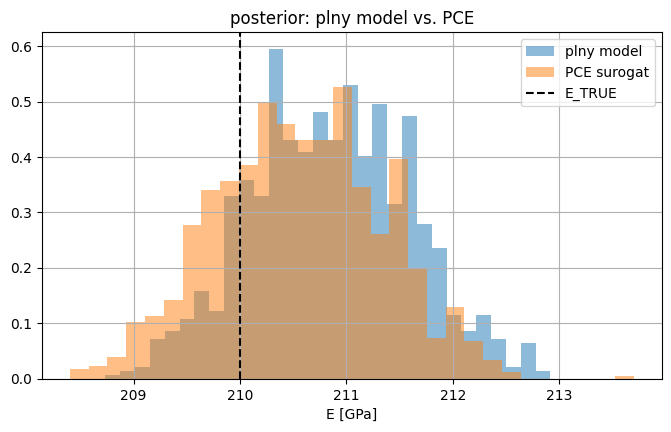

In [42]:
vzorky_pce = mcmc_pce.samples[:, 0]
odhad_pce = vzorky_pce.mean()
chyba_pce = abs(odhad_pce - E_TRUE) / E_TRUE * 100
rozdil_metod = abs(odhad_full - odhad_pce) / odhad_full * 100

print(f"E_TRUE                : {E_TRUE/1e9:7.2f} GPa")
print(f"posterior plny model  : {odhad_full/1e9:7.2f} +/- {vzorky_full.std()/1e9:5.2f} GPa   (chyba {chyba_full:.2f} %)")
print(f"posterior PCE         : {odhad_pce/1e9:7.2f} +/- {vzorky_pce.std()/1e9:5.2f} GPa   (chyba {chyba_pce:.2f} %)")
print(f"rozdil mezi metodami  : {rozdil_metod:.2f} %")
print(f"cas: plny model {cas_full:.1f} s, PCE {cas_pce:.3f} s  ->  zrychleni {cas_full/cas_pce:.0f}x")

if rozdil_metod < 5:
    print("shoda plneho modelu a PCE je v poradku")

plt.figure()
plt.hist(vzorky_full/1e9, bins=30, alpha=0.5, density=True, label='plny model')
plt.hist(vzorky_pce/1e9, bins=30, alpha=0.5, density=True, label='PCE surogat')
plt.axvline(E_TRUE/1e9, color='k', ls='--', label='E_TRUE')
plt.xlabel('E [GPa]')
plt.title('posterior: plny model vs. PCE')
plt.legend()
plt.show()
